# World Cup 2026 Prediction: Logistic Regression + Monte Carlo
ISYE 6740 - Group 127

## Overview

A multinomial logistic regression model that predicts win/draw/loss for World Cup matches (2002-2022) from
team-feature differences: top-5-league count, connectivity, log population, log GDP per capita,
FIFA rank, and host status. The fitted model's parameters are exported for the group's Monte Carlo
simulation of the 2026 bracket.

## Method notes

- Features are all measured before each tournament, so nothing looks into the future. Evaluation
  is fit on 2002-2018, and tested on 2022, with the scaler fit on training
  years only.
- Each match is stored twice with the teams and outcome flipped, so the model does not depend on
  which team is listed as "home" (other than true host status).
- Outcomes come from actual match scores, so group-stage draws are preserved
 - the three 2010 North Korea matches are dropped (no published GDP).

## Key findings (for the report)

- On the 2022 test set the model reaches 0.547 accuracy and 1.027 log loss, beating a class-rate
  baseline (1.075) and close to the "pick the higher-ranked team" heuristic on accuracy while
  giving calibrated probabilities the simulation can use.
- Top-5-league count is the strongest predictor, followed by FIFA rank and host status. Connectivity has an unexpected negative coefficient, likely overlapping with
  top-5-league count. Draws barely separate on any feature, so the model doesn't do a great job at predicting them.
- Against the completed 2026 tournament, the model's top four were England, United States, France,
  and Spain (all ~8.5-10%). The actual champion, Spain, was in that top four; England and France
  reached the final stages while the United States exited in the round of 16 - a reminder of how
  much single-elimination outcomes swing on low-probability events.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

rng = np.random.default_rng(6740)

import os
results_file = "final_results.csv" if os.path.exists("final_results.csv") else "results.csv"
print("using", results_file)
results = pd.read_csv(results_file)
results["date"] = pd.to_datetime(results["date"])
results["year"] = results["date"].dt.year

wc = results[(results["tournament"] == "FIFA World Cup") & (results["year"] >= 2002)].copy()
wc.groupby("year").size()

using final_results.csv


year
2002     64
2006     64
2010     64
2014     64
2018     64
2022     64
2026    104
dtype: int64

## Team feature vectors

In [2]:
hosts = {}
for y, grp in wc.groupby("year"):
    teams = set(grp["home_team"]) | set(grp["away_team"])
    hosts[y] = set(grp["country"].unique()) & teams

# final_results.csv is match-level with home_/away_ feature columns; unstack it
# into one row per (year, team) so we can look up either side of any matchup.
home = wc[["year","home_team","home_top5_league_count","home_connectivity",
           "home_population","home_gdp_per_capita","home_fifa_rank"]].copy()
home.columns = ["year","team","top5_league_count","connectivity","population","gdp_per_capita","fifa_rank"]
away = wc[["year","away_team","away_top5_league_count","away_connectivity",
           "away_population","away_gdp_per_capita","away_fifa_rank"]].copy()
away.columns = home.columns
team_year = pd.concat([home, away]).dropna(subset=["fifa_rank"]).drop_duplicates(["year","team"])

team_year["log_pop"] = np.log(team_year["population"])
team_year["log_gdp_pc"] = np.log(team_year["gdp_per_capita"])
fcols = ["top5_league_count","connectivity","log_pop","log_gdp_pc","fifa_rank"]
team_feats = team_year.set_index(["year","team"])[fcols]

def match_features(year, team1, team2):
    f1, f2 = team_feats.loc[(year, team1)], team_feats.loc[(year, team2)]
    d = (f1 - f2).tolist()
    d.append(int(team1 in hosts[year]) - int(team2 in hosts[year]))
    return d

xcols = [c + "_diff" for c in fcols] + ["host_diff"]
hosts

{2002: {'Japan', 'South Korea'},
 2006: {'Germany'},
 2010: {'South Africa'},
 2014: {'Brazil'},
 2018: {'Russia'},
 2022: {'Qatar'},
 2026: {'Canada', 'Mexico', 'United States'}}

## Training matches

In [3]:
rows = []
inv = {"win":"loss", "loss":"win", "draw":"draw"}
played = wc[(wc["year"] <= 2022) & wc["home_score"].notna()]
for _, m in played.iterrows():
    # three-way outcome from the actual scores (draws preserved for the group stage)
    if m["home_score"] > m["away_score"]:
        res = "win"
    elif m["home_score"] < m["away_score"]:
        res = "loss"
    else:
        res = "draw"
    x = match_features(m["year"], m["home_team"], m["away_team"])
    if any(pd.isna(x)):
        continue
    rows.append([m["year"], m["home_team"], m["away_team"], res] + x)
    rows.append([m["year"], m["away_team"], m["home_team"], inv[res]] + [-v for v in x])

data = pd.DataFrame(rows, columns=["year","team1","team2","result"] + xcols)
print("matches:", len(data)//2)
data["result"].value_counts(normalize=True).round(3)

matches: 381


result
loss    0.385
win     0.385
draw    0.231
Name: proportion, dtype: float64

## Model

## Feature separation by outcome

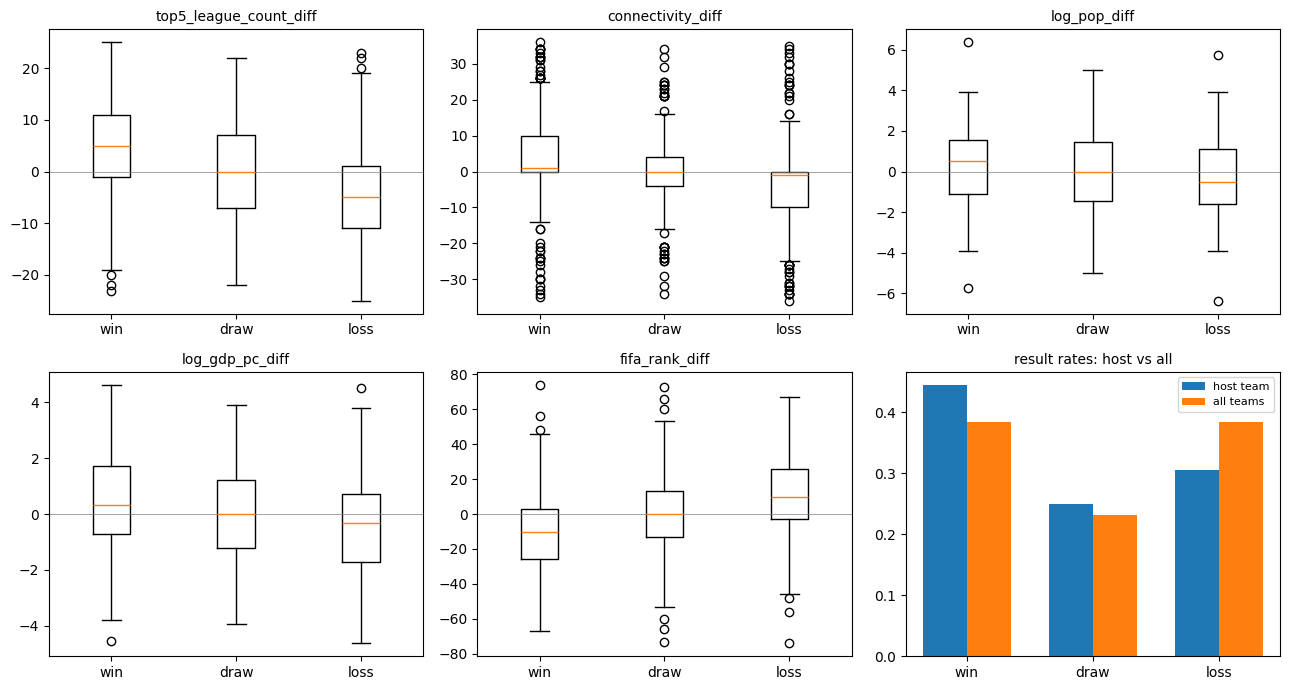

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
order = ["win", "draw", "loss"]
for ax, c in zip(axes.flat[:5], xcols[:5]):
    ax.boxplot([data.loc[data["result"] == r, c] for r in order], tick_labels=order)
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_title(c, fontsize=10)
ax = axes.flat[5]
host_rates = data.loc[data["host_diff"] == 1, "result"].value_counts(normalize=True).reindex(order)
all_rates = data["result"].value_counts(normalize=True).reindex(order)
w = 0.35; x = np.arange(3)
ax.bar(x - w/2, host_rates, w, label="host team")
ax.bar(x + w/2, all_rates, w, label="all teams")
ax.set_xticks(x, order); ax.set_title("result rates: host vs all", fontsize=10); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig_feature_separation.png", dpi=150)
plt.show()

## Feature correlation check

Top-5-league count and connectivity both measure squad strength in related ways, so before fitting
we check whether they move together. Strongly correlated features make coefficients unstable -
logistic regression can split their shared effect into offsetting large positive and negative
values, so individual signs become unreliable. This is worth checking up front to interpret the
coefficients correctly later.

In [5]:
corr = data[["top5_league_count_diff", "connectivity_diff"]].corr().iloc[0, 1]
print(f"correlation between top5_league_count_diff and connectivity_diff: {corr:.3f}")

correlation between top5_league_count_diff and connectivity_diff: 0.816


## Regularization strength (C)

The default logistic regression uses C = 1. We tune C by cross-validation on the training years
only (2002-2018), never touching 2022 or 2026. Stronger regularization (smaller C) shrinks
coefficients toward zero, which helps when features are correlated. We pick the C with the best
mean log loss across folds, since the simulation depends on calibrated probabilities.

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

train = data[data["year"] <= 2018]

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=6740)),
])
grid = GridSearchCV(
    pipe,
    {"clf__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10]},
    scoring="neg_log_loss",
    cv=5,
)
grid.fit(train[xcols], train["result"])
best_C = grid.best_params_["clf__C"]
print("best C:", best_C, "| CV log loss:", round(-grid.best_score_, 3))
pd.DataFrame(grid.cv_results_)[["param_clf__C", "mean_test_score"]].assign(
    mean_log_loss=lambda d: (-d["mean_test_score"]).round(3)
)[["param_clf__C", "mean_log_loss"]]

best C: 0.03 | CV log loss: 0.978


,param_clf__C,mean_log_loss
0,0.01,0.982
1,0.03,0.978
2,0.10,0.980
3,0.30,0.982
4,1.00,0.984
5,3.00,0.985
6,10.00,0.985


## Ablation: does dropping connectivity help?

Because connectivity is correlated with top-5-league count and had an unstable coefficient, we
compare the full feature set against one with connectivity removed - both tuned and evaluated the
same way - to see whether it actually contributes out-of-sample.

In [7]:
test = data[(data["year"] == 2022) & (data.index % 2 == 0)]

def fit_eval(cols, C):
    sc = StandardScaler().fit(data[data["year"] <= 2018][cols])
    tr = data[data["year"] <= 2018]
    m = LogisticRegression(C=C, max_iter=1000, random_state=6740)
    m.fit(sc.transform(tr[cols]), tr["result"])
    p = m.predict_proba(sc.transform(test[cols]))
    return (round(accuracy_score(test["result"], m.predict(sc.transform(test[cols]))), 3),
            round(log_loss(test["result"], p, labels=m.classes_), 3))

xcols_noconn = [c for c in xcols if c != "connectivity_diff"]
for label, cols in [("full", xcols), ("no connectivity", xcols_noconn)]:
    acc, ll = fit_eval(cols, best_C)
    print(f"{label:16s} accuracy {acc}  log loss {ll}")

full             accuracy 0.547  log loss 1.027
no connectivity  accuracy 0.547  log loss 1.028


## Fit and evaluate: train 2002-2018, test 2022

In [8]:
train = data[data["year"] <= 2018]
test = data[(data["year"] == 2022) & (data.index % 2 == 0)]
scaler = StandardScaler().fit(train[xcols])

model = LogisticRegression(C=best_C, max_iter=1000, random_state=6740)
model.fit(scaler.transform(train[xcols]), train["result"])

pred = model.predict(scaler.transform(test[xcols]))
proba = model.predict_proba(scaler.transform(test[xcols]))
base = train["result"].value_counts(normalize=True).reindex(model.classes_).values
fav = np.where(test["fifa_rank_diff"] < 0, "win", "loss")

print("test accuracy:", round(accuracy_score(test["result"], pred), 3))
print("pick-better-rank accuracy:", round(accuracy_score(test["result"], fav), 3))
print("test log loss:", round(log_loss(test["result"], proba, labels=model.classes_), 3))
print("class-rate baseline log loss:", round(log_loss(test["result"], np.tile(base, (len(test),1)), labels=model.classes_), 3))
pd.DataFrame(model.coef_, index=model.classes_, columns=xcols).round(3)

test accuracy: 0.547
pick-better-rank accuracy: 0.562
test log loss: 1.027
class-rate baseline log loss: 1.075


,top5_league_count_diff,connectivity_diff,log_pop_diff,log_gdp_pc_diff,fifa_rank_diff,host_diff
draw,-0.000,-0.000,-0.000,-0.000,0.000,-0.000
loss,-0.297,0.015,-0.023,-0.107,0.253,-0.158
win,0.297,-0.015,0.023,0.107,-0.253,0.158


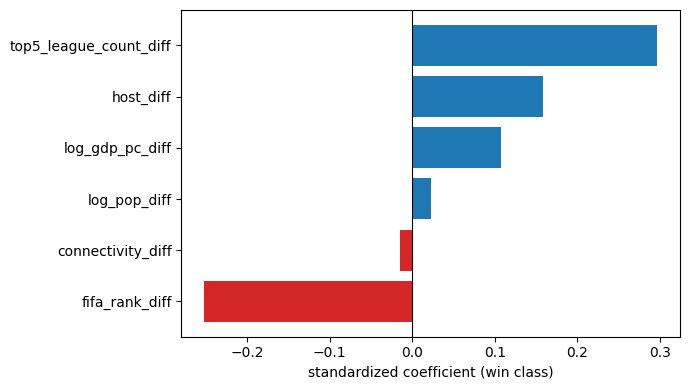

In [9]:
coefs = pd.Series(model.coef_[list(model.classes_).index("win")], index=xcols).sort_values()
plt.figure(figsize=(7, 4))
plt.barh(coefs.index, coefs.values, color=np.where(coefs.values > 0, "tab:blue", "tab:red"))
plt.axvline(0, color="black", lw=0.8)
plt.xlabel("standardized coefficient (win class)")
plt.tight_layout()
plt.savefig("fig_coefficients.png", dpi=150)
plt.show()

## Calibration (leave-one-tournament-out)

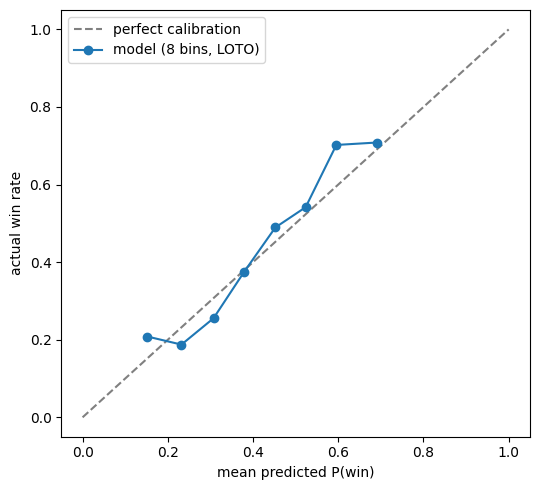

In [10]:
loto_pred, loto_won = [], []
for y in sorted(data["year"].unique()):
    tr = data[data["year"] != y]
    te = data[(data["year"] == y) & (data.index % 2 == 0)]
    sc = StandardScaler().fit(tr[xcols])
    m = LogisticRegression(C=best_C, max_iter=1000, random_state=6740).fit(sc.transform(tr[xcols]), tr["result"])
    loto_pred += list(m.predict_proba(sc.transform(te[xcols]))[:, list(m.classes_).index("win")])
    loto_won += list((te["result"] == "win").values)

bins = pd.qcut(np.array(loto_pred), 8)
cal = pd.DataFrame({"pred": loto_pred, "won": loto_won}).groupby(bins, observed=True).mean()
plt.figure(figsize=(5.5, 5))
plt.plot([0, 1], [0, 1], "--", color="gray", label="perfect calibration")
plt.plot(cal["pred"], cal["won"], "o-", label="model (8 bins, LOTO)")
plt.xlabel("mean predicted P(win)"); plt.ylabel("actual win rate")
plt.legend(); plt.tight_layout()
plt.savefig("fig_calibration.png", dpi=150)
plt.show()

## Final model and 2026 pairwise probabilities

In [11]:
scaler_f = StandardScaler().fit(data[xcols])
final = LogisticRegression(C=best_C, max_iter=1000, random_state=6740)
final.fit(scaler_f.transform(data[xcols]), data["result"])

wc26 = wc[wc["year"] == 2026].sort_values("date")
teams26 = sorted(set(wc26["home_team"]) | set(wc26["away_team"]))
idx = {t: i for i, t in enumerate(teams26)}
ci = {c: k for k, c in enumerate(final.classes_)}

X = pd.DataFrame([match_features(2026, t1, t2) for t1 in teams26 for t2 in teams26 if t1 != t2],
                 columns=xcols)
probs = final.predict_proba(scaler_f.transform(X))
P = np.zeros((48, 48, 3))
k = 0
for t1 in teams26:
    for t2 in teams26:
        if t1 == t2: continue
        P[idx[t1], idx[t2]] = probs[k]; k += 1
pw, pdr, pl = P[:,:,ci["win"]], P[:,:,ci["draw"]], P[:,:,ci["loss"]]

## Model handoff for the simulation

In [12]:
import json

params = {
    "features": xcols,
    "feature_notes": {
        "diffs": "team1 value minus team2 value, using team_tournament_features.csv",
        "log_pop": "np.log(population)", "log_gdp_pc": "np.log(gdp_per_capita)",
        "host_diff": "1 if team1 is a host, minus 1 if team2 is a host",
    },
    "scaler_mean": scaler_f.mean_.tolist(),
    "scaler_scale": scaler_f.scale_.tolist(),
    "classes": final.classes_.tolist(),
    "coef": final.coef_.tolist(),
    "intercept": final.intercept_.tolist(),
    "training": "World Cup matches 2002-2022, mirrored, N.Korea 2010 dropped",
}
with open("model_parameters.json", "w") as f:
    json.dump(params, f, indent=2)

x = np.array(match_features(2026, "Argentina", "France"))
z = (x - np.array(params["scaler_mean"])) / np.array(params["scaler_scale"])
s = np.array(params["coef"]) @ z + np.array(params["intercept"])
manual = np.exp(s) / np.exp(s).sum()
sk = final.predict_proba(scaler_f.transform(pd.DataFrame([x], columns=xcols)))[0]
print("classes:", params["classes"])
print("manual softmax:", manual.round(4))
print("sklearn:       ", sk.round(4))

classes: ['draw', 'loss', 'win']
manual softmax: [0.2501 0.4402 0.3097]
sklearn:        [0.2501 0.4402 0.3097]


## Reconstruct the 12 groups from the schedule

In [13]:
group_matches = wc26[wc26["date"] <= "2026-06-27"]
adj = {t: set() for t in teams26}
for _, m in group_matches.iterrows():
    adj[m["home_team"]].add(m["away_team"])
    adj[m["away_team"]].add(m["home_team"])

groups, seen = [], set()
for t in teams26:
    if t not in seen:
        comp = {t} | adj[t]
        for u in list(comp):
            comp |= adj[u]
        groups.append(sorted(comp))
        seen |= comp
groups

[['Algeria', 'Argentina', 'Austria', 'Jordan'],
 ['Australia', 'Paraguay', 'Turkey', 'United States'],
 ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
 ['Bosnia and Herzegovina', 'Canada', 'Qatar', 'Switzerland'],
 ['Brazil', 'Haiti', 'Morocco', 'Scotland'],
 ['Cape Verde', 'Saudi Arabia', 'Spain', 'Uruguay'],
 ['Colombia', 'DR Congo', 'Portugal', 'Uzbekistan'],
 ['Croatia', 'England', 'Ghana', 'Panama'],
 ['Curaçao', 'Ecuador', 'Germany', 'Ivory Coast'],
 ['Czech Republic', 'Mexico', 'South Africa', 'South Korea'],
 ['France', 'Iraq', 'Norway', 'Senegal'],
 ['Japan', 'Netherlands', 'Sweden', 'Tunisia']]

## Monte Carlo simulation (validation preview)

In [14]:
def sim_group(g):
    pts = {t: 0 for t in g}
    for a in range(4):
        for b in range(a+1, 4):
            i, j = idx[g[a]], idx[g[b]]
            u = rng.random()
            if u < pw[i,j]: pts[g[a]] += 3
            elif u < pw[i,j] + pdr[i,j]: pts[g[a]] += 1; pts[g[b]] += 1
            else: pts[g[b]] += 3
    order = sorted(g, key=lambda t: (pts[t], rng.random()), reverse=True)
    return order, pts

def sim_knockout_match(t1, t2):
    i, j = idx[t1], idx[t2]
    u = rng.random()
    if u < pw[i,j]: return t1
    if u < pw[i,j] + pdr[i,j]: return t1 if rng.random() < 0.5 else t2
    return t2

def pair_round_of_32(field, gmap):
    for _ in range(200):
        order = list(rng.permutation(field))
        pairs = [(order[i], order[i+1]) for i in range(0, 32, 2)]
        if all(gmap[a] != gmap[b] for a, b in pairs):
            return pairs
    return pairs

def sim_tournament():
    gmap, field, thirds = {}, [], []
    for gi, g in enumerate(groups):
        order, pts = sim_group(g)
        for t in g: gmap[t] = gi
        field += order[:2]
        thirds.append((pts[order[2]], rng.random(), order[2]))
    thirds.sort(reverse=True)
    field += [t for _, _, t in thirds[:8]]
    rounds = {32: None, 16: None, 8: None, 4: None, 2: None}
    reached = {t: 32 for t in field}
    while len(field) > 1:
        if len(field) == 32:
            pairs = pair_round_of_32(field, gmap)
        else:
            order = list(rng.permutation(field))
            pairs = [(order[i], order[i+1]) for i in range(0, len(order), 2)]
        field = [sim_knockout_match(a, b) for a, b in pairs]
        for t in field: reached[t] = len(field)
    return field[0], reached

n_sims = 10000
titles = {t: 0 for t in teams26}
semis = {t: 0 for t in teams26}
for _ in range(n_sims):
    w, reached = sim_tournament()
    titles[w] += 1
    for t, r in reached.items():
        if r <= 4: semis[t] += 1

summary = pd.DataFrame({
    "P(champion)": pd.Series(titles) / n_sims,
    "P(reach semifinal)": pd.Series(semis) / n_sims,
}).sort_values("P(champion)", ascending=False)
summary.head(15).round(4)

,P(champion),P(reach semifinal)
England,0.1026,0.2836
United States,0.0990,0.2802
France,0.0976,0.2696
Spain,0.0849,0.2575
Germany,0.0739,0.2342
Netherlands,0.0600,0.2036
Argentina,0.0595,0.1969
Switzerland,0.0547,0.2024
Belgium,0.0524,0.1940
Mexico,0.0388,0.1609


## Reality check against the 2026 tournament

In [15]:
stage = pd.Series("group", index=teams26)
bounds = [("2026-06-28","R32"), ("2026-07-04","R16"), ("2026-07-08","QF"),
          ("2026-07-11","SF"), ("2026-07-14","final")]
for start, name in bounds:
    ms = wc26[wc26["date"] >= start]
    for t in set(ms["home_team"]) | set(ms["away_team"]):
        stage[t] = name
final_match = wc26[wc26["date"] == wc26["date"].max()].iloc[0]
champion = final_match["home_team"] if final_match["home_score"] > final_match["away_score"] else final_match["away_team"]
stage[champion] = "champion"

out = summary.head(12).copy()
out["actual stage reached"] = stage.reindex(out.index)
out.round(3)

,P(champion),P(reach semifinal),actual stage reached
England,0.103,0.284,final
United States,0.099,0.280,R16
France,0.098,0.270,final
Spain,0.085,0.258,champion
Germany,0.074,0.234,R32
Netherlands,0.060,0.204,R32
Argentina,0.060,0.197,final
Switzerland,0.055,0.202,SF
Belgium,0.052,0.194,QF
Mexico,0.039,0.161,R16


## Sensitivity: does the manager's nationality help?

In [16]:
coach = pd.read_excel("world_cup_coach_nationality_and_ranking_2010_2026.xlsx",
                      skiprows=5, header=None, usecols=range(8),
                      names=["year","team","coach","coach_nat","same_nation","pedigree","tier","rank_in_tourn"])
coach = coach.dropna(subset=["team"])
coach["team"] = coach["team"].replace({"Czechia":"Czech Republic", "Türkiye":"Turkey"})
same = coach.set_index(["year","team"])["same_nation"].astype(bool)

d10 = data[data["year"] >= 2010].copy()
d10["same_nation_diff"] = [int(same.loc[(y, t1)]) - int(same.loc[(y, t2)])
                           for y, t1, t2 in zip(d10["year"], d10["team1"], d10["team2"])]

tr = d10[d10["year"] <= 2018]
te = d10[(d10["year"] == 2022) & (d10.index % 2 == 0)]
for cols, label in [(xcols, "without coach"), (xcols + ["same_nation_diff"], "with coach")]:
    sc = StandardScaler().fit(tr[cols])
    m = LogisticRegression(max_iter=1000, random_state=6740).fit(sc.transform(tr[cols]), tr["result"])
    p = m.predict_proba(sc.transform(te[cols]))
    print(label, "- log loss:", round(log_loss(te["result"], p, labels=m.classes_), 3),
          "| accuracy:", round(accuracy_score(te["result"], m.predict(sc.transform(te[cols]))), 3))

without coach - log loss: 1.053 | accuracy: 0.516
with coach - log loss: 1.043 | accuracy: 0.516


## Limitations